In [9]:

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as np
from jax import vmap, jit

import numpy as onp
import pandas as pd
#from scipy.integrate import odeint
#from scipy.special import gammaln
import pandas as pd
from matplotlib import pyplot as plt
import os

# modules from particles
import particles  # core module
from particles import distributions as dists  # where probability distributions are defined
from particles import state_space_models as ssm  # where state-space models are defined
from particles.collectors import Moments
from particles import mcmc  # where the MCMC algorithms (PMMH, Particle Gibbs, etc) live

from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt, PIDController


In [10]:
## particles only works with an old version of scipy

%load_ext watermark
%watermark -n -u -v -iv -w

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Tue, 06 Oct 2026

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.17.1

diffrax   : 0.7.2
jax       : 0.5.3
matplotlib: 3.11.2
numpy     : 1.26.4
pandas    : 3.0.6
particles : 0.4

Watermark: 2.6.0



In [11]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-paper')
plt.style.use('dark_background')


In [12]:

# we will carry out the simulations on proportions, and convert to per 100K rates
@jit
def simple_flu(t, x, p):
    # unpack vectors
    beta, gamma, delta, epsilon, theta, mu = p
    S, V, I, H, R, H_cum = x

    # Force of infection
    lambda_inf = beta*I

    dS_dt = -lambda_inf*S - delta*S
    dV_dt = -epsilon*lambda_inf*V + delta*S
    dI_dt = lambda_inf*(S + epsilon*V) - gamma*I
    dH_dt = gamma*theta*I - mu*H
    dR_dt = gamma*(1 - theta)*I + mu*H
    dH_cum_dt = gamma*theta*I

    return np.array([dS_dt,dV_dt,dI_dt,dH_dt,dR_dt,dH_cum_dt])

## create objects for ode solver
odeterm = ODETerm(simple_flu)
odesolver = Tsit5()
odestepsize = PIDController(rtol=1e-6, atol=1e-6)

## used in PX() of state space model:
@jit
def onestep(prev, p):
    deltaT = 7.0
    ## leaving out "saveat" saves only t1
    next = diffeqsolve(odeterm, odesolver, t0=0., t1=deltaT, dt0=None, y0=prev, args=p, stepsize_controller=odestepsize)
    return next.ys[0]

## vectorizes and jax-compiles onestep() for calling on a batch of particles
## the particles are a matrix with dims [# particles, # compartments]
## returns a matrix with same shape
batch_onestep = jit(vmap(onestep, in_axes=(0,None)))


In [13]:

# Note to self: vector-valued inputs to parameters for univariate distributions yields one distribution for each value
# which is used when you evaluate for each particle
class FluPart(ssm.StateSpaceModel):

    default_params = {'beta':0.8,'gamma':0.2,'epsilon':0.05,
                    'delta':0.0,'theta':0.35,'mu':0.2,'sigma_meas':0.1}

    def PX0(self):  # Distribution of X_0
        nonS = np.array([0.47,0.001,0,0])  # V,I,H,R
        y0 = np.array([1.0 - np.sum(nonS), *nonS, 1e-9])
        component_distributions = [dists.Dirac(loc=y0[j]) for j in range(y0.shape[0])]
        return dists.IndepProd(*component_distributions)

    def PX(self, t, xp):  # Distribution of X_t given X_{t-1}=xp (p=past)
        p = [self.beta, self.gamma, self.delta, self.epsilon, self.theta, self.mu]
        totals = batch_onestep(xp, p)
        component_distributions = [dists.Dirac(loc=totals[:, j]) for j in range(totals.shape[1])]
        return dists.IndepProd(*component_distributions)
        
    def PY(self, t, xp, x):  # Distribution of Y_t given X_t=x (and possibly X_{t-1}=xp)
        ## xp is unavailable at t0
        y = x[:,5] if xp is None else (x[:,5] - xp[:,5])
        return dists.LogNormal(mu=np.log(y+1e-9), sigma=self.sigma_meas)


In [ ]:

#construct a prior for our model

##
## note: sampling fails with any dirac priors
## for fixed params, leave out of prior and set inside model
##
prior_dict = {
        "beta": dists.Gamma(4.0,6.0),  # likely using alpha-beta parametrization, mean = a/b
        "theta": dists.Beta(21.0,40.0),
        "sigma_meas": dists.Gamma(10.0,1000.0)
        }

# definition of model and prior
my_prior = dists.StructDist(prior_dict)

In [15]:
# acquire data
datafile = os.path.join("C:\\", "Users", "User", "python_code", "start_point", "nbeats_flu", "data", "FluSurveillance_Custom_Download_Data.csv")
#C:\Users\User\python_code\start_point\nbeats_flu\data\FluSurveillance_Custom_Download_Data.csv

# cumulative rate hospitalized is per one hundred thousand, so we normalize all data sources by 10**5
usecols=["YEAR", "WEEK", "AGE CATEGORY", "RACE CATEGORY", "SEX CATEGORY", "VIRUS TYPE CATEGORY", "CUMULATIVE RATE"]
df = pd.read_csv(datafile, usecols=usecols)
overall_data = df[df["AGE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["RACE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["SEX CATEGORY"]=="Overall"].reset_index(drop=True)
flu_A = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza A"].reset_index(drop=True)
flu_B = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza B"].reset_index(drop=True)
both = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Overall"].reset_index(drop=True)

flu_A_cases = np.array(flu_A["CUMULATIVE RATE"])/10**5
flu_A_incident = np.diff(flu_A_cases[30:60], prepend=0.0) + 1e-9 # 30:60 is 2010 flu season
flu_B_cases = np.array(flu_B["CUMULATIVE RATE"])/10**5
flu_B_incident = np.diff(flu_B_cases[30:60], prepend=0.0) + 1e-9
both_cases = np.array(both["CUMULATIVE RATE"])/10**5
time_series = both_cases[30:60]
incident_cases = np.diff(time_series, prepend=0.0) + 1e-9
both_strain_incident = np.stack([flu_A_incident, flu_B_incident])


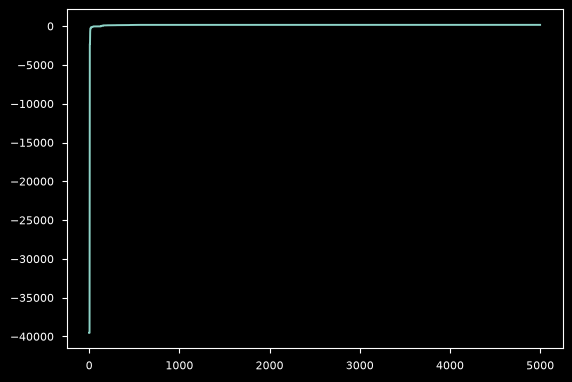

In [16]:
# perform filtering for full problem
pmmh = mcmc.PMMH(ssm_cls=FluPart, prior=my_prior, data=incident_cases, Nx=50, niter = 5000)
pmmh.run()
plt.plot(pmmh.chain.lpost)

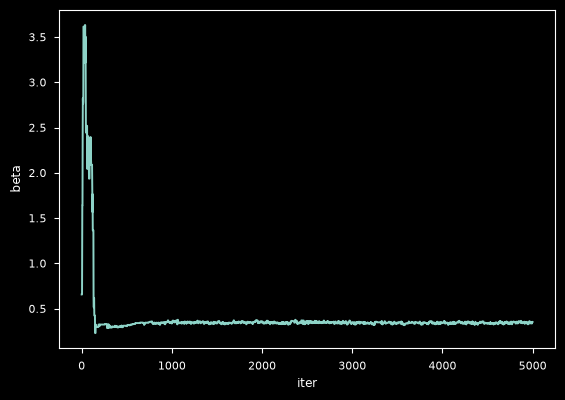

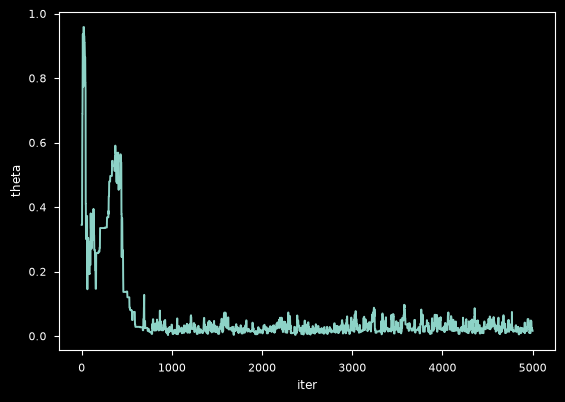

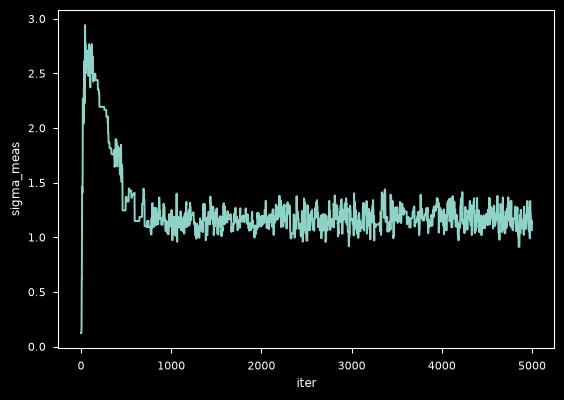

In [17]:
for p in prior_dict.keys():  # loop over mu, theta, rho
     plt.figure()
     plt.plot(pmmh.chain.theta[p])
     plt.xlabel('iter')
     plt.ylabel(p)
     plt.show()